In [1]:
import os
os.makedirs("../outputs/eda/", exist_ok=True)

## Load Data

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("../HR_data_2/HR_data_2.csv") 

# Basic view
df.head()

,Unnamed: 0,HR_TD_Mean,HR_TD_Median,HR_TD_std,HR_TD_Min,HR_TD_Max,HR_TD_AUC,HR_TD_Kurtosis,HR_TD_Skew,HR_TD_Slope_min,...,upset,hostile,alert,ashamed,inspired,nervous,attentive,afraid,active,determined
0,0,78.663878,76.70,7.480043,67.25,92.48,23048.450,-1.091448,0.369955,-0.7300,...,1.0,1.0,2.0,1.0,2.0,2.0,3.0,1.0,2.0,2.0
1,1,76.540732,76.61,2.584756,69.82,82.33,23959.920,-0.245338,0.338732,-0.3600,...,2.0,1.0,3.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0
2,2,78.173563,77.92,2.681255,72.22,82.80,20324.605,-0.615922,-0.233047,-0.6300,...,1.0,1.0,2.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0
3,3,83.073688,83.88,7.363598,69.42,96.12,24924.300,-0.866610,-0.046021,-0.4650,...,1.0,1.0,2.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0
4,4,72.281250,72.91,3.193762,64.95,79.98,23052.100,0.200401,-0.560948,-0.3725,...,3.0,1.0,3.0,2.0,3.0,3.0,4.0,2.0,4.0,4.0


In [3]:
df['Team_num'] = df['Team_ID'].str.extract(r'Team(\d+)')
df['Team_num'] = df['Team_num'].astype(int)

In [4]:
df[['Team_ID', 'Team_num']].drop_duplicates().head(10)

,Team_ID,Team_num
0,D1_4_Team10,10
24,D1_4_Team11,11
48,D1_6_Team13,13
72,D1_1_Team4,4
96,D1_1_Team2,2
108,D1_1_Team1,1
132,D1_1_Team3,3
168,D1_2_Team2,2
180,D1_2_Team1,1
192,D1_2_Team3,3


In [5]:
print("Missing values in Team_num:", df['Team_num'].isnull().sum())

Missing values in Team_num: 0


In [6]:
df.head()

,Unnamed: 0,HR_TD_Mean,HR_TD_Median,HR_TD_std,HR_TD_Min,HR_TD_Max,HR_TD_AUC,HR_TD_Kurtosis,HR_TD_Skew,HR_TD_Slope_min,...,hostile,alert,ashamed,inspired,nervous,attentive,afraid,active,determined,Team_num
0,0,78.663878,76.70,7.480043,67.25,92.48,23048.450,-1.091448,0.369955,-0.7300,...,1.0,2.0,1.0,2.0,2.0,3.0,1.0,2.0,2.0,10
1,1,76.540732,76.61,2.584756,69.82,82.33,23959.920,-0.245338,0.338732,-0.3600,...,1.0,3.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0,10
2,2,78.173563,77.92,2.681255,72.22,82.80,20324.605,-0.615922,-0.233047,-0.6300,...,1.0,2.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0,10
3,3,83.073688,83.88,7.363598,69.42,96.12,24924.300,-0.866610,-0.046021,-0.4650,...,1.0,2.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0,10
4,4,72.281250,72.91,3.193762,64.95,79.98,23052.100,0.200401,-0.560948,-0.3725,...,1.0,3.0,2.0,3.0,3.0,4.0,2.0,4.0,4.0,10


## Check modified dataset overview 

In [7]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

Shape: (312, 72)

Columns:
 ['Unnamed: 0', 'HR_TD_Mean', 'HR_TD_Median', 'HR_TD_std', 'HR_TD_Min', 'HR_TD_Max', 'HR_TD_AUC', 'HR_TD_Kurtosis', 'HR_TD_Skew', 'HR_TD_Slope_min', 'HR_TD_Slope_max', 'HR_TD_Slope_mean', 'HR_TD_Slope', 'TEMP_TD_Mean', 'TEMP_TD_Median', 'TEMP_TD_std', 'TEMP_TD_Min', 'TEMP_TD_Max', 'TEMP_TD_AUC', 'TEMP_TD_Kurtosis', 'TEMP_TD_Skew', 'TEMP_TD_Slope_min', 'TEMP_TD_Slope_max', 'TEMP_TD_Slope_mean', 'TEMP_TD_Slope', 'EDA_TD_P_Mean', 'EDA_TD_P_Median', 'EDA_TD_P_std', 'EDA_TD_P_Min', 'EDA_TD_P_Max', 'EDA_TD_P_AUC', 'EDA_TD_P_Kurtosis', 'EDA_TD_P_Skew', 'EDA_TD_P_Slope_min', 'EDA_TD_P_Slope_max', 'EDA_TD_P_Slope_mean', 'EDA_TD_P_Slope', 'EDA_TD_T_Mean', 'EDA_TD_T_Median', 'EDA_TD_T_std', 'EDA_TD_T_Min', 'EDA_TD_T_Max', 'EDA_TD_T_AUC', 'EDA_TD_T_Kurtosis', 'EDA_TD_T_Skew', 'EDA_TD_T_Slope_min', 'EDA_TD_T_Slope_max', 'EDA_TD_T_Slope_mean', 'EDA_TD_T_Slope', 'EDA_TD_P_Peaks', 'EDA_TD_P_RT', 'EDA_TD_P_ReT', 'Round', 'Phase', 'Individual', 'Puzzler', 'original_ID', 'raw_d

Data types and missing values

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 312 entries, 0 to 311
Data columns (total 72 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           312 non-null    int64  
 1   HR_TD_Mean           312 non-null    float64
 2   HR_TD_Median         312 non-null    float64
 3   HR_TD_std            312 non-null    float64
 4   HR_TD_Min            312 non-null    float64
 5   HR_TD_Max            312 non-null    float64
 6   HR_TD_AUC            312 non-null    float64
 7   HR_TD_Kurtosis       312 non-null    float64
 8   HR_TD_Skew           312 non-null    float64
 9   HR_TD_Slope_min      312 non-null    float64
 10  HR_TD_Slope_max      312 non-null    float64
 11  HR_TD_Slope_mean     312 non-null    float64
 12  HR_TD_Slope          312 non-null    float64
 13  TEMP_TD_Mean         312 non-null    float64
 14  TEMP_TD_Median       312 non-null    float64
 15  TEMP_TD_std          312 non-null    float64
 16  T

In [9]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

inspired        2
determined      2
active          1
afraid          1
EDA_TD_P_RT     1
EDA_TD_P_ReT    1
attentive       1
dtype: int64


In [10]:
print("Phases:", df["Phase"].unique())
print("Rounds:", df["Round"].unique())
print("Individuals:", df["Individual"].nunique())

Phases: <StringArray>
['phase3', 'phase2', 'phase1']
Length: 3, dtype: str
Rounds: <StringArray>
['round_3', 'round_2', 'round_4', 'round_1']
Length: 4, dtype: str
Individuals: 26


In [11]:
counts = df.groupby("Individual").size()
print(counts.describe())
print(counts.head())

count    26.0
mean     12.0
std       0.0
min      12.0
25%      12.0
50%      12.0
75%      12.0
max      12.0
dtype: float64
Individual
1    12
2    12
3    12
4    12
5    12
dtype: int64


In [12]:
print(df["Phase"].value_counts())

Phase
phase3    104
phase2    104
phase1    104
Name: count, dtype: int64


In [13]:
pd.crosstab(df["Round"], df["Phase"])

Phase,phase1,phase2,phase3
Round,,,
round_1,26,26,26
round_2,26,26,26
round_3,26,26,26
round_4,26,26,26


Separate feature types

In [14]:
# Core physiological feature groups used across EDA, correlation, and PCA
hr_features = [col for col in df.columns if col.startswith("HR_")]
temp_features = [col for col in df.columns if col.startswith("TEMP_")]
eda_p_features = [col for col in df.columns if col.startswith("EDA_TD_P_")]
eda_t_features = [col for col in df.columns if col.startswith("EDA_TD_T_")]

# Combined physiological feature list
physio_cols = hr_features + temp_features + eda_p_features + eda_t_features

# Metadata
meta_cols = ["Phase", "Round", "Individual", "Team_num", "Team_ID", "Cohort", "Puzzler"]

# Questionnaire
questionnaire_cols = [
    "Frustrated","upset","hostile","alert","ashamed","inspired",
    "nervous","attentive","afraid","active","determined"
]

In [15]:
print("Physio features:", len(physio_cols))
print("Metadata:", meta_cols)
print("emotional features:", len(questionnaire_cols))

Physio features: 51
Metadata: ['Phase', 'Round', 'Individual', 'Team_num', 'Team_ID', 'Cohort', 'Puzzler']
emotional features: 11


Statistical summary

In [16]:
df[physio_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
HR_TD_Mean,312.0,78.549974,11.382695,5.760612e+01,7.106124e+01,76.784284,83.566296,151.942434
HR_TD_Median,312.0,77.452869,12.093798,5.413000e+01,6.997125e+01,75.600000,83.108750,167.950000
HR_TD_std,312.0,6.545680,4.998885,8.343897e-01,3.160342e+00,4.919862,8.006694,32.155396
HR_TD_Min,312.0,68.778365,9.341107,4.900000e+01,6.219250e+01,67.565000,73.805000,111.070000
HR_TD_Max,312.0,92.451122,17.759683,6.720000e+01,8.020750e+01,87.830000,99.452500,172.470000
HR_TD_AUC,312.0,24307.558590,4035.278119,1.485326e+04,2.154905e+04,23650.430000,26543.927500,46069.990000
HR_TD_Kurtosis,312.0,-0.054661,1.671170,-1.644825e+00,-9.844733e-01,-0.456978,0.216412,12.510032
HR_TD_Skew,312.0,0.375978,0.823875,-2.230501e+00,-1.510220e-01,0.361195,0.988498,3.225347
HR_TD_Slope_min,312.0,-0.567952,0.391239,-3.366000e+00,-6.652083e-01,-0.457500,-0.317500,-0.112500
HR_TD_Slope_max,312.0,0.518478,0.470043,7.500000e-02,2.925000e-01,0.412500,0.613750,6.202500


In [17]:
low_var = df[physio_cols].std().sort_values()
print(low_var.head(10))

TEMP_TD_Slope          0.000304
TEMP_TD_Slope_mean     0.000314
TEMP_TD_Slope_min      0.000792
TEMP_TD_Slope_max      0.000857
EDA_TD_P_Slope         0.001162
EDA_TD_P_Slope_mean    0.001416
EDA_TD_T_Slope         0.001603
EDA_TD_T_Slope_mean    0.001625
EDA_TD_T_Slope_max     0.039443
HR_TD_Slope_mean       0.051248
dtype: float64


In [18]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## Signal Sanity check for Questionnair response

In [19]:
df.groupby("Phase")[questionnaire_cols].mean()

,Frustrated,upset,hostile,alert,ashamed,inspired,nervous,attentive,afraid,active,determined
Phase,,,,,,,,,,,
phase1,1.076923,1.105769,1.028846,1.990385,1.096154,2.049020,1.451923,2.611650,1.077670,2.184466,2.796117
phase2,3.201923,1.663462,1.115385,2.701923,1.403846,2.461538,1.451923,3.355769,1.057692,3.278846,3.394231
phase3,1.788462,1.269231,1.028846,1.884615,1.163462,2.038462,1.240385,2.384615,1.019231,2.192308,2.543689


## Signal Sanity check for Physiological Features

HR features

In [20]:
hr_cols = [col for col in df.columns if col.startswith("HR_")]

df.groupby("Phase")[hr_cols].mean()

,HR_TD_Mean,HR_TD_Median,HR_TD_std,HR_TD_Min,HR_TD_Max,HR_TD_AUC,HR_TD_Kurtosis,HR_TD_Skew,HR_TD_Slope_min,HR_TD_Slope_max,HR_TD_Slope_mean,HR_TD_Slope
Phase,,,,,,,,,,,,
phase1,78.546709,77.517308,7.116225,67.694038,94.098558,23842.325192,0.257866,0.367507,-0.670524,0.613486,-0.016208,-0.016975
phase2,79.821439,78.778462,6.588371,69.629327,92.868365,25490.858365,-0.415210,0.226248,-0.510774,0.516538,-0.002918,-0.003391
phase3,77.281774,76.062837,5.932446,69.011731,90.386442,23589.492212,-0.006640,0.534181,-0.522558,0.425410,-0.021238,-0.021607


Temp features

In [21]:
temp_cols = [col for col in df.columns if col.startswith("TEMP_")]

df.groupby("Phase")[temp_cols].mean()

,TEMP_TD_Mean,TEMP_TD_Median,TEMP_TD_std,TEMP_TD_Min,TEMP_TD_Max,TEMP_TD_AUC,TEMP_TD_Kurtosis,TEMP_TD_Skew,TEMP_TD_Slope_min,TEMP_TD_Slope_max,TEMP_TD_Slope_mean,TEMP_TD_Slope
Phase,,,,,,,,,,,,
phase1,32.850516,32.845817,0.116839,32.639615,33.082596,40134.742452,-0.443971,0.062594,-0.000836,0.000990,0.000090,0.000093
phase2,32.953082,32.955096,0.085387,32.774712,33.115769,42195.669471,-0.478960,-0.067310,-0.000658,0.000623,-0.000020,-0.000021
phase3,32.912368,32.906442,0.123226,32.696538,33.145769,40294.852308,-0.397792,-0.009483,-0.000914,0.000892,0.000024,0.000028


EDA features

In [22]:
eda_cols = [col for col in df.columns if col.startswith("EDA_")]

df.groupby("Phase")[eda_cols].mean()

,EDA_TD_P_Mean,EDA_TD_P_Median,EDA_TD_P_std,EDA_TD_P_Min,EDA_TD_P_Max,EDA_TD_P_AUC,EDA_TD_P_Kurtosis,EDA_TD_P_Skew,EDA_TD_P_Slope_min,EDA_TD_P_Slope_max,...,EDA_TD_T_AUC,EDA_TD_T_Kurtosis,EDA_TD_T_Skew,EDA_TD_T_Slope_min,EDA_TD_T_Slope_max,EDA_TD_T_Slope_mean,EDA_TD_T_Slope,EDA_TD_P_Peaks,EDA_TD_P_RT,EDA_TD_P_ReT
Phase,,,,,,,,,,,,,,,,,,,,,
phase1,0.291864,0.203223,0.302254,-0.045080,1.607864,353.411317,14.924516,3.305624,-0.039338,0.044252,...,4323.398097,0.424226,-0.095934,-0.027097,0.022276,-0.000325,-0.000280,19.846154,2.105254,2.121922
phase2,0.596686,0.497114,0.423987,-0.018579,2.295783,752.023293,8.367708,2.397390,-0.047111,0.064187,...,4348.132841,0.300596,0.052906,-0.033267,0.029925,0.000128,0.000199,32.384615,1.829868,1.765578
phase3,0.365332,0.246751,0.370936,-0.036932,2.028741,442.830192,14.705649,3.235362,-0.045800,0.061058,...,5260.569760,0.601089,-0.202467,-0.033378,0.027044,-0.000434,-0.000353,18.326923,2.060781,2.155321


## Prepared Aggregated Data

In [23]:
phase_means = df.groupby("Phase").mean(numeric_only=True)

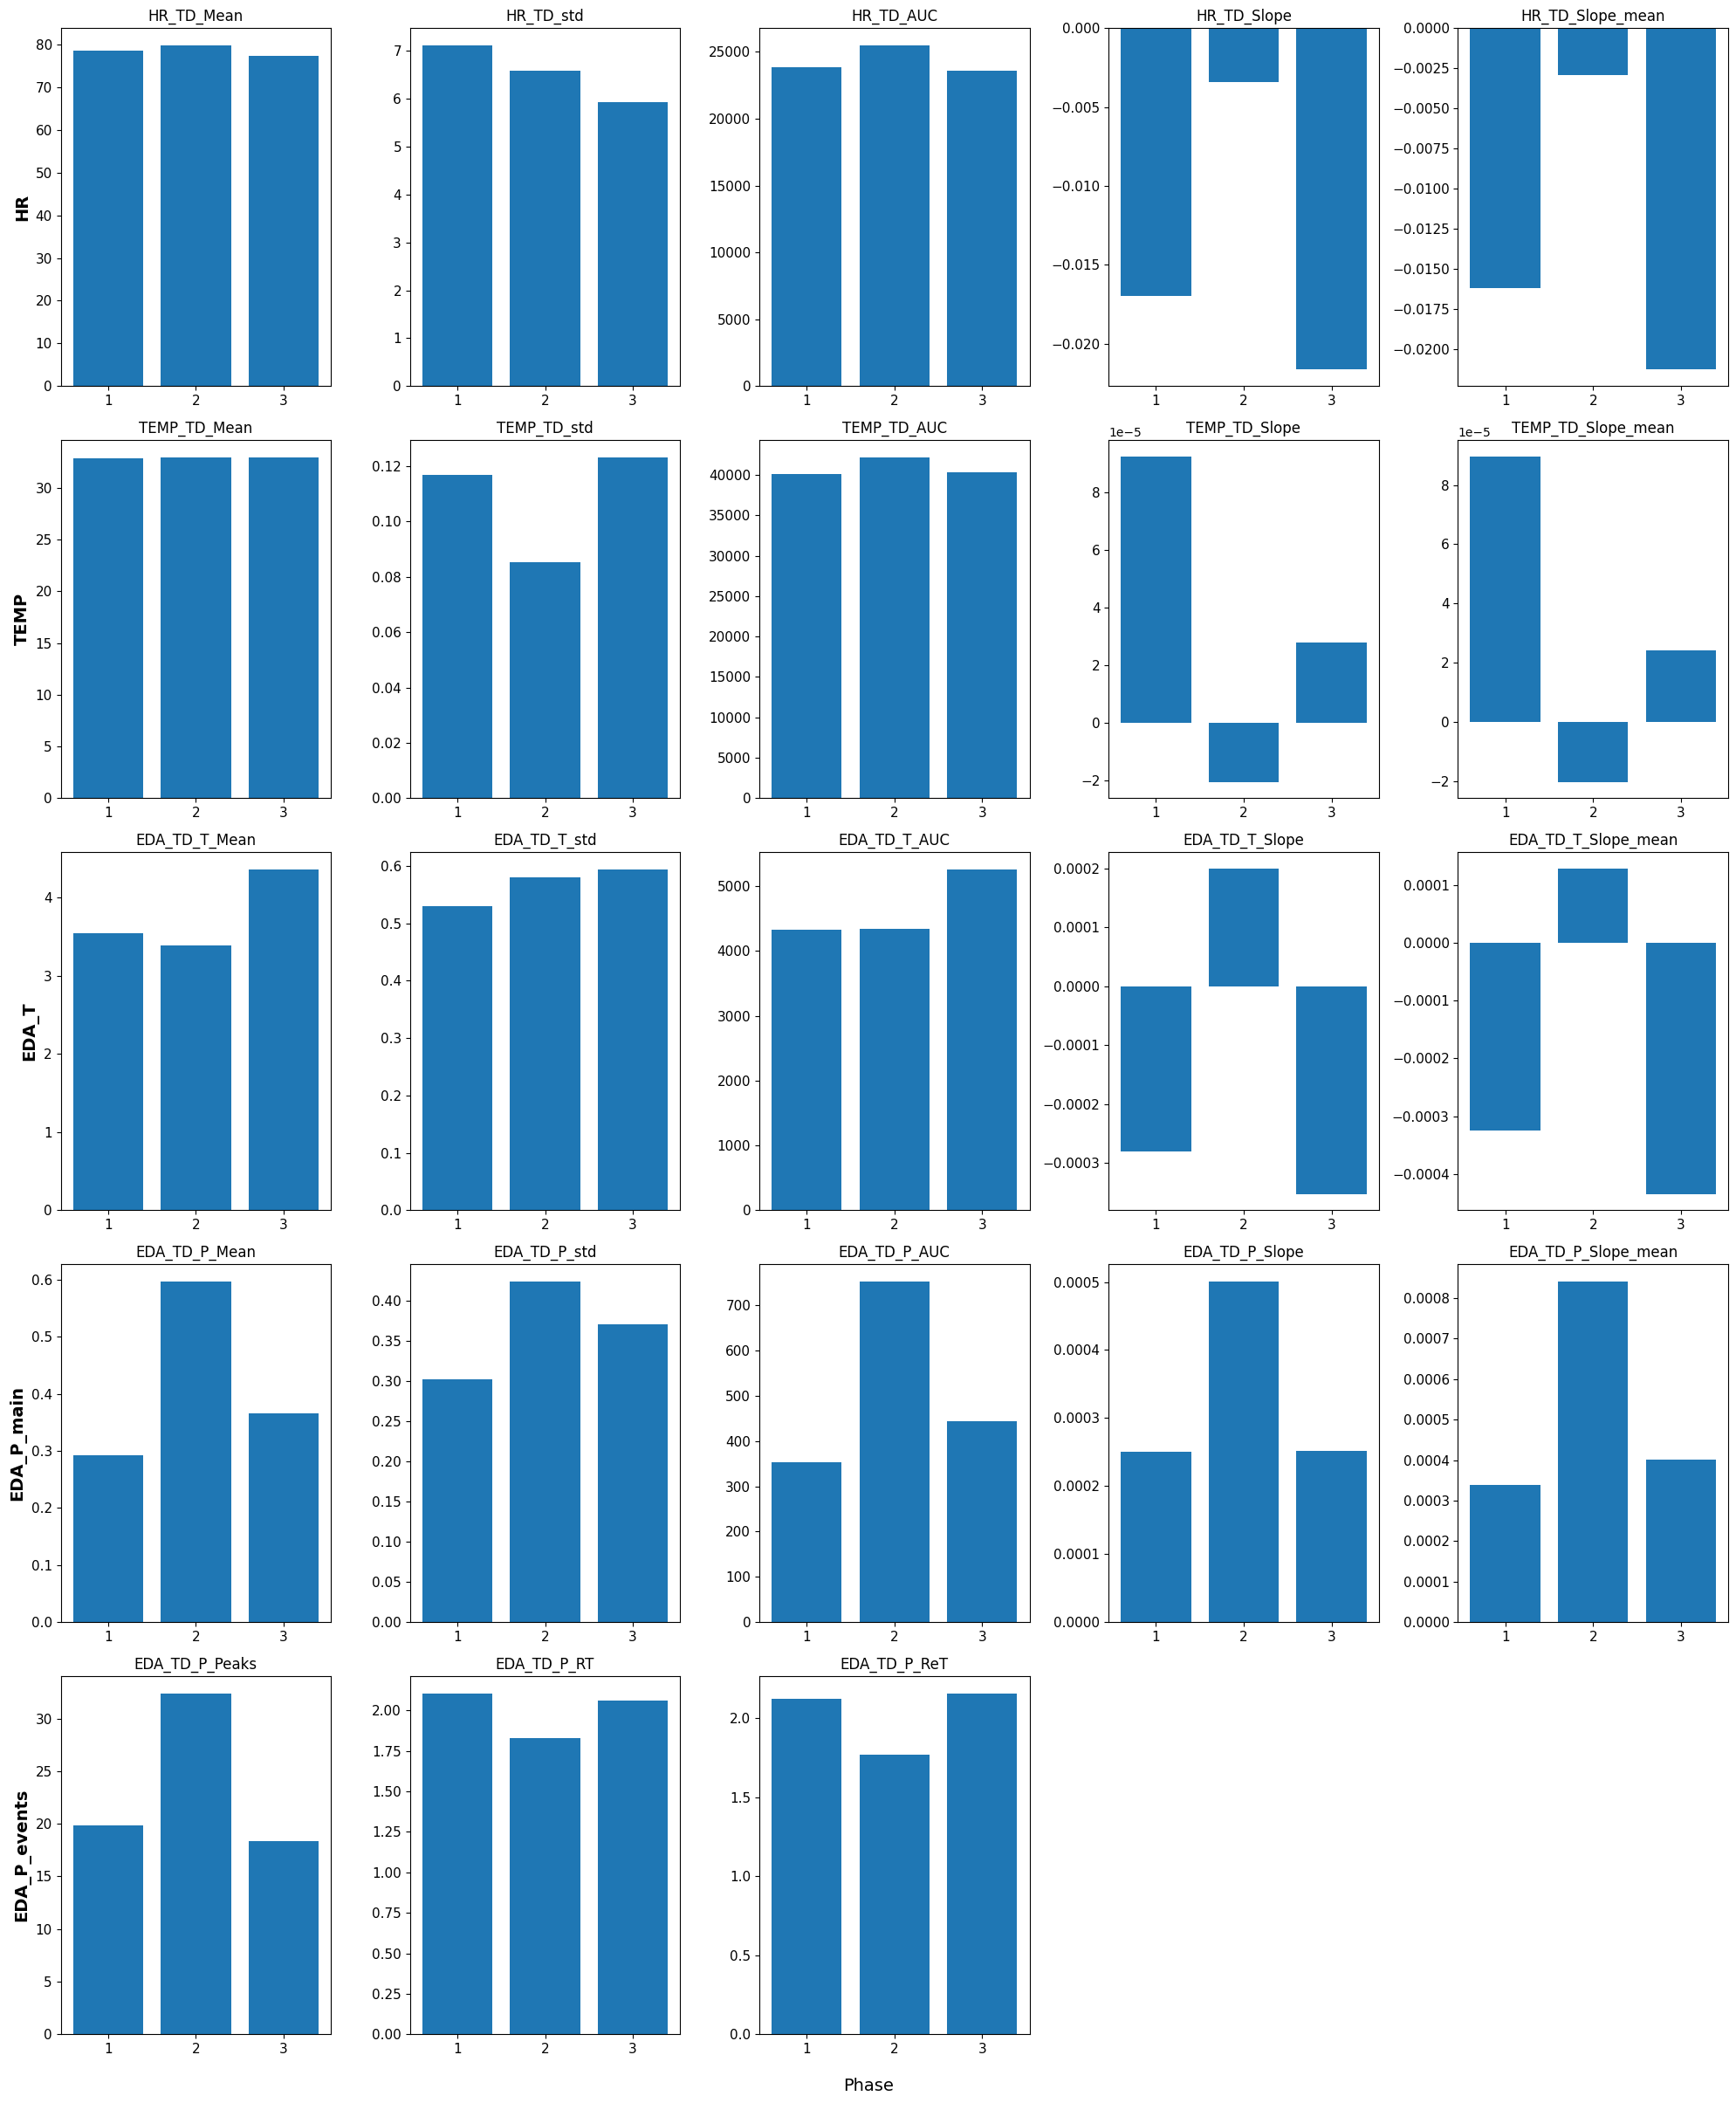

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Step 1: Phase-wise mean ---
phase_means = df.groupby("Phase").mean(numeric_only=True)

# Convert phase labels to 1,2,3
phase_labels = ['1', '2', '3']

# --- Step 2: Feature groups ---
groups = {
    "HR": [
        'HR_TD_Mean',
        'HR_TD_std',
        'HR_TD_AUC',
        'HR_TD_Slope',
        'HR_TD_Slope_mean'
    ],
    
    "TEMP": [
        'TEMP_TD_Mean',
        'TEMP_TD_std',
        'TEMP_TD_AUC',
        'TEMP_TD_Slope',
        'TEMP_TD_Slope_mean'
    ],
    
    "EDA_T": [
        'EDA_TD_T_Mean',
        'EDA_TD_T_std',
        'EDA_TD_T_AUC',
        'EDA_TD_T_Slope',
        'EDA_TD_T_Slope_mean'
    ],
    
    "EDA_P_main": [
        'EDA_TD_P_Mean',
        'EDA_TD_P_std',
        'EDA_TD_P_AUC',
        'EDA_TD_P_Slope',
        'EDA_TD_P_Slope_mean'
    ],
    
    "EDA_P_events": [
        'EDA_TD_P_Peaks',
        'EDA_TD_P_RT',
        'EDA_TD_P_ReT'
    ]
    
}

# --- Step 3: Create subplot grid ---
n_rows = len(groups)
n_cols = max(len(v) for v in groups.values())

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 5*n_rows))

# --- Step 4: Plot ---
for row_idx, (group_name, features) in enumerate(groups.items()):
    
    for col_idx in range(n_cols):
        
        ax = axes[row_idx, col_idx]
        
        if col_idx < len(features):
            feature = features[col_idx]
            values = phase_means[feature]
            
            ax.bar([0,1,2], values)
            
            # Titles and labels (larger fonts)
            ax.set_title(feature, fontsize=12)
            ax.set_xticks([0,1,2])
            ax.set_xticklabels(phase_labels, fontsize=11)
            ax.tick_params(axis='y', labelsize=11)
            
        else:
            ax.axis("off")
    
    # Row label (bigger)
    axes[row_idx, 0].set_ylabel(group_name, fontsize=14, fontweight='bold')

# --- Step 5: Common X label ---
fig.text(0.5, 0.04, 'Phase', ha='center', fontsize=14)

# --- Step 6: Layout ---
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("../outputs/eda/mean physiological features.png")
plt.show()

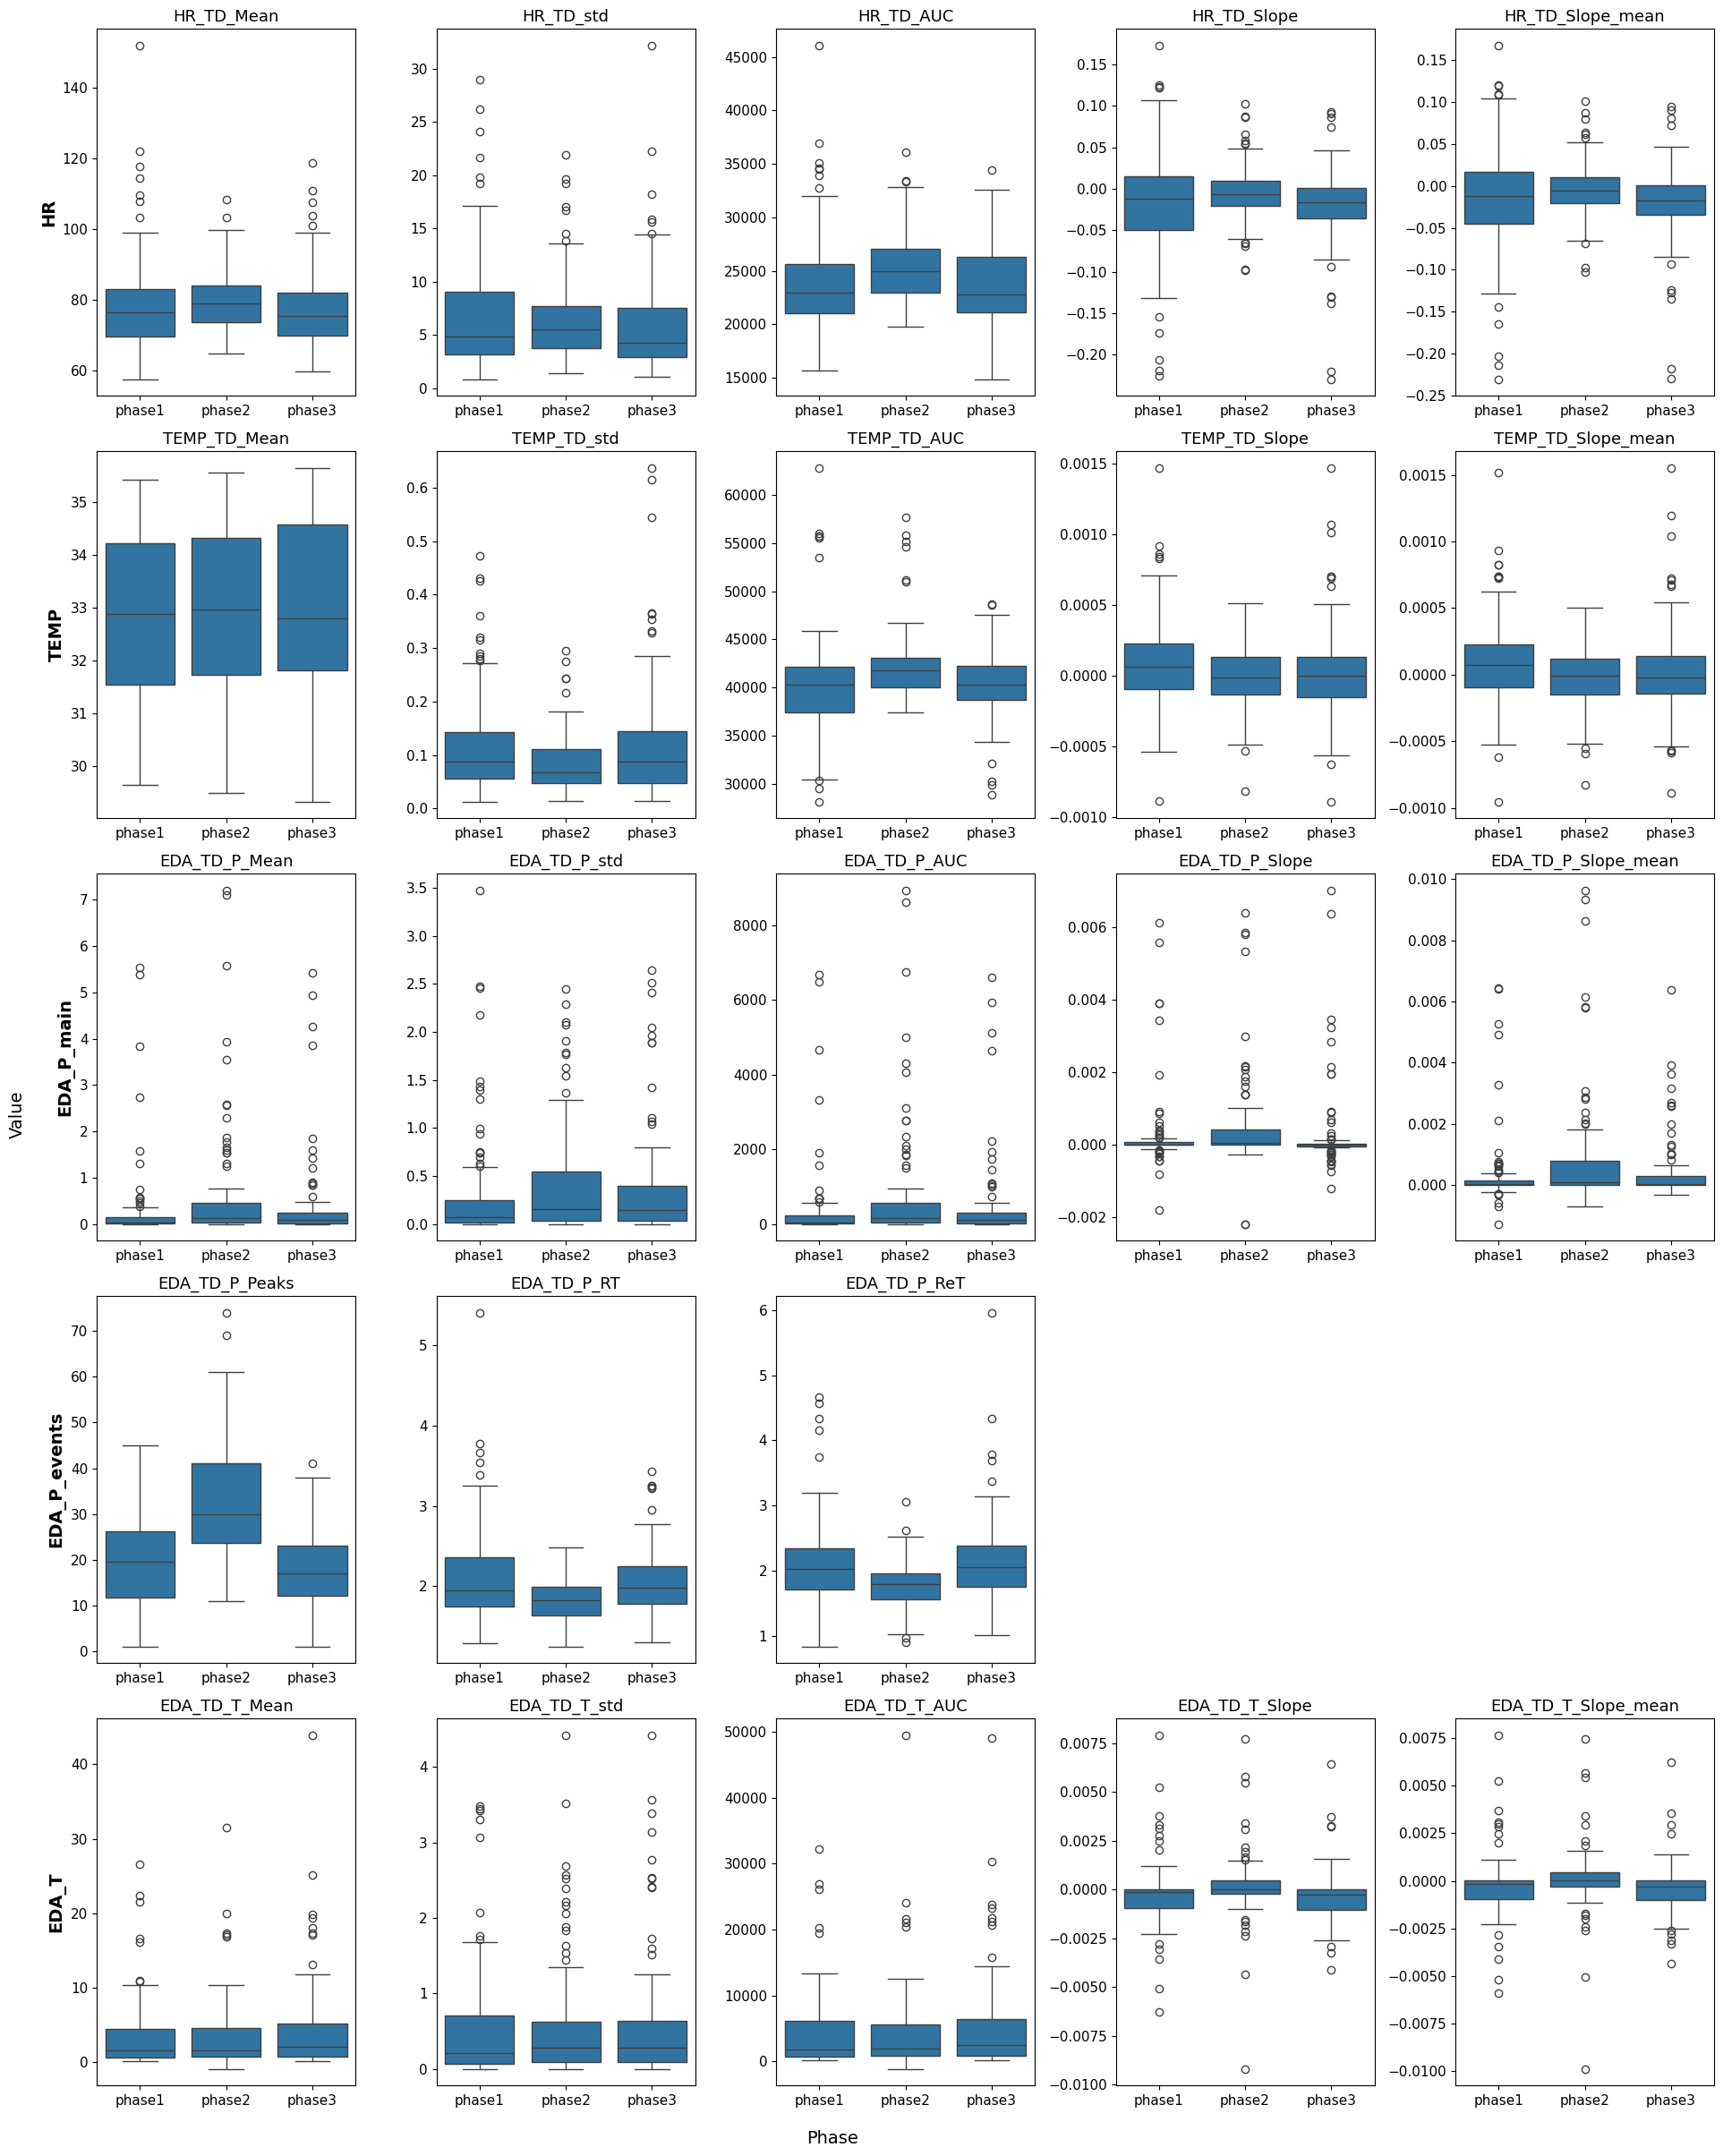

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Feature groups ---
groups = {
    "HR": [
        'HR_TD_Mean',
        'HR_TD_std',
        'HR_TD_AUC',
        'HR_TD_Slope',
        'HR_TD_Slope_mean'
    ],
    
    "TEMP": [
        'TEMP_TD_Mean',
        'TEMP_TD_std',
        'TEMP_TD_AUC',
        'TEMP_TD_Slope',
        'TEMP_TD_Slope_mean'
    ],
    
    "EDA_P_main": [
        'EDA_TD_P_Mean',
        'EDA_TD_P_std',
        'EDA_TD_P_AUC',
        'EDA_TD_P_Slope',
        'EDA_TD_P_Slope_mean'
    ],
    
    "EDA_P_events": [
        'EDA_TD_P_Peaks',
        'EDA_TD_P_RT',
        'EDA_TD_P_ReT'
    ],
    
    "EDA_T": [
        'EDA_TD_T_Mean',
        'EDA_TD_T_std',
        'EDA_TD_T_AUC',
        'EDA_TD_T_Slope',
        'EDA_TD_T_Slope_mean'
    ]
}

# --- Setup ---
n_rows = len(groups)
n_cols = max(len(v) for v in groups.values())

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 5*n_rows))

# --- Plot ---
for row_idx, (group_name, features) in enumerate(groups.items()):
    
    for col_idx in range(n_cols):
        ax = axes[row_idx, col_idx]
        
        if col_idx < len(features):
            feature = features[col_idx]
            
            sns.boxplot(
                data=df,
                x="Phase",
                y=feature,
                ax=ax,
                order=["phase1", "phase2", "phase3"]
            )
            
            ax.set_title(feature, fontsize=13)
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.tick_params(axis='both', labelsize=11)
        
        else:
            ax.axis("off")
    
    # Row label
    axes[row_idx, 0].set_ylabel(group_name, fontsize=14, fontweight='bold')

# --- Global labels ---
fig.text(0.5, 0.04, 'Phase', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Value', va='center', rotation='vertical', fontsize=14)

plt.tight_layout(rect=[0.05, 0.05, 1, 1])
plt.savefig("../outputs/eda/box plot of physiological features.png")
plt.show()

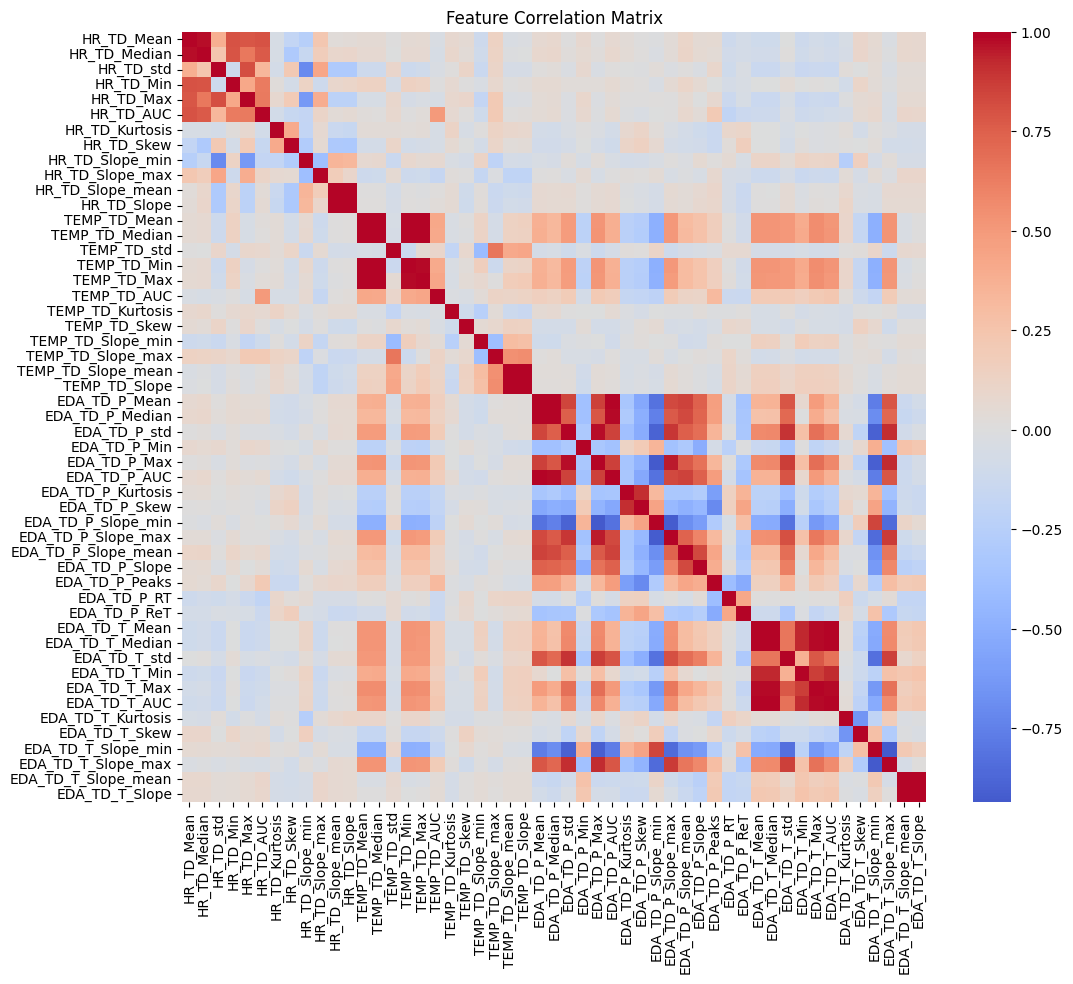

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_features = hr_features + temp_features + eda_p_features + eda_t_features

corr = df[selected_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.savefig("../outputs/eda/correlation heatmap physiological features.png")
plt.show()

Player correlation on physiological features

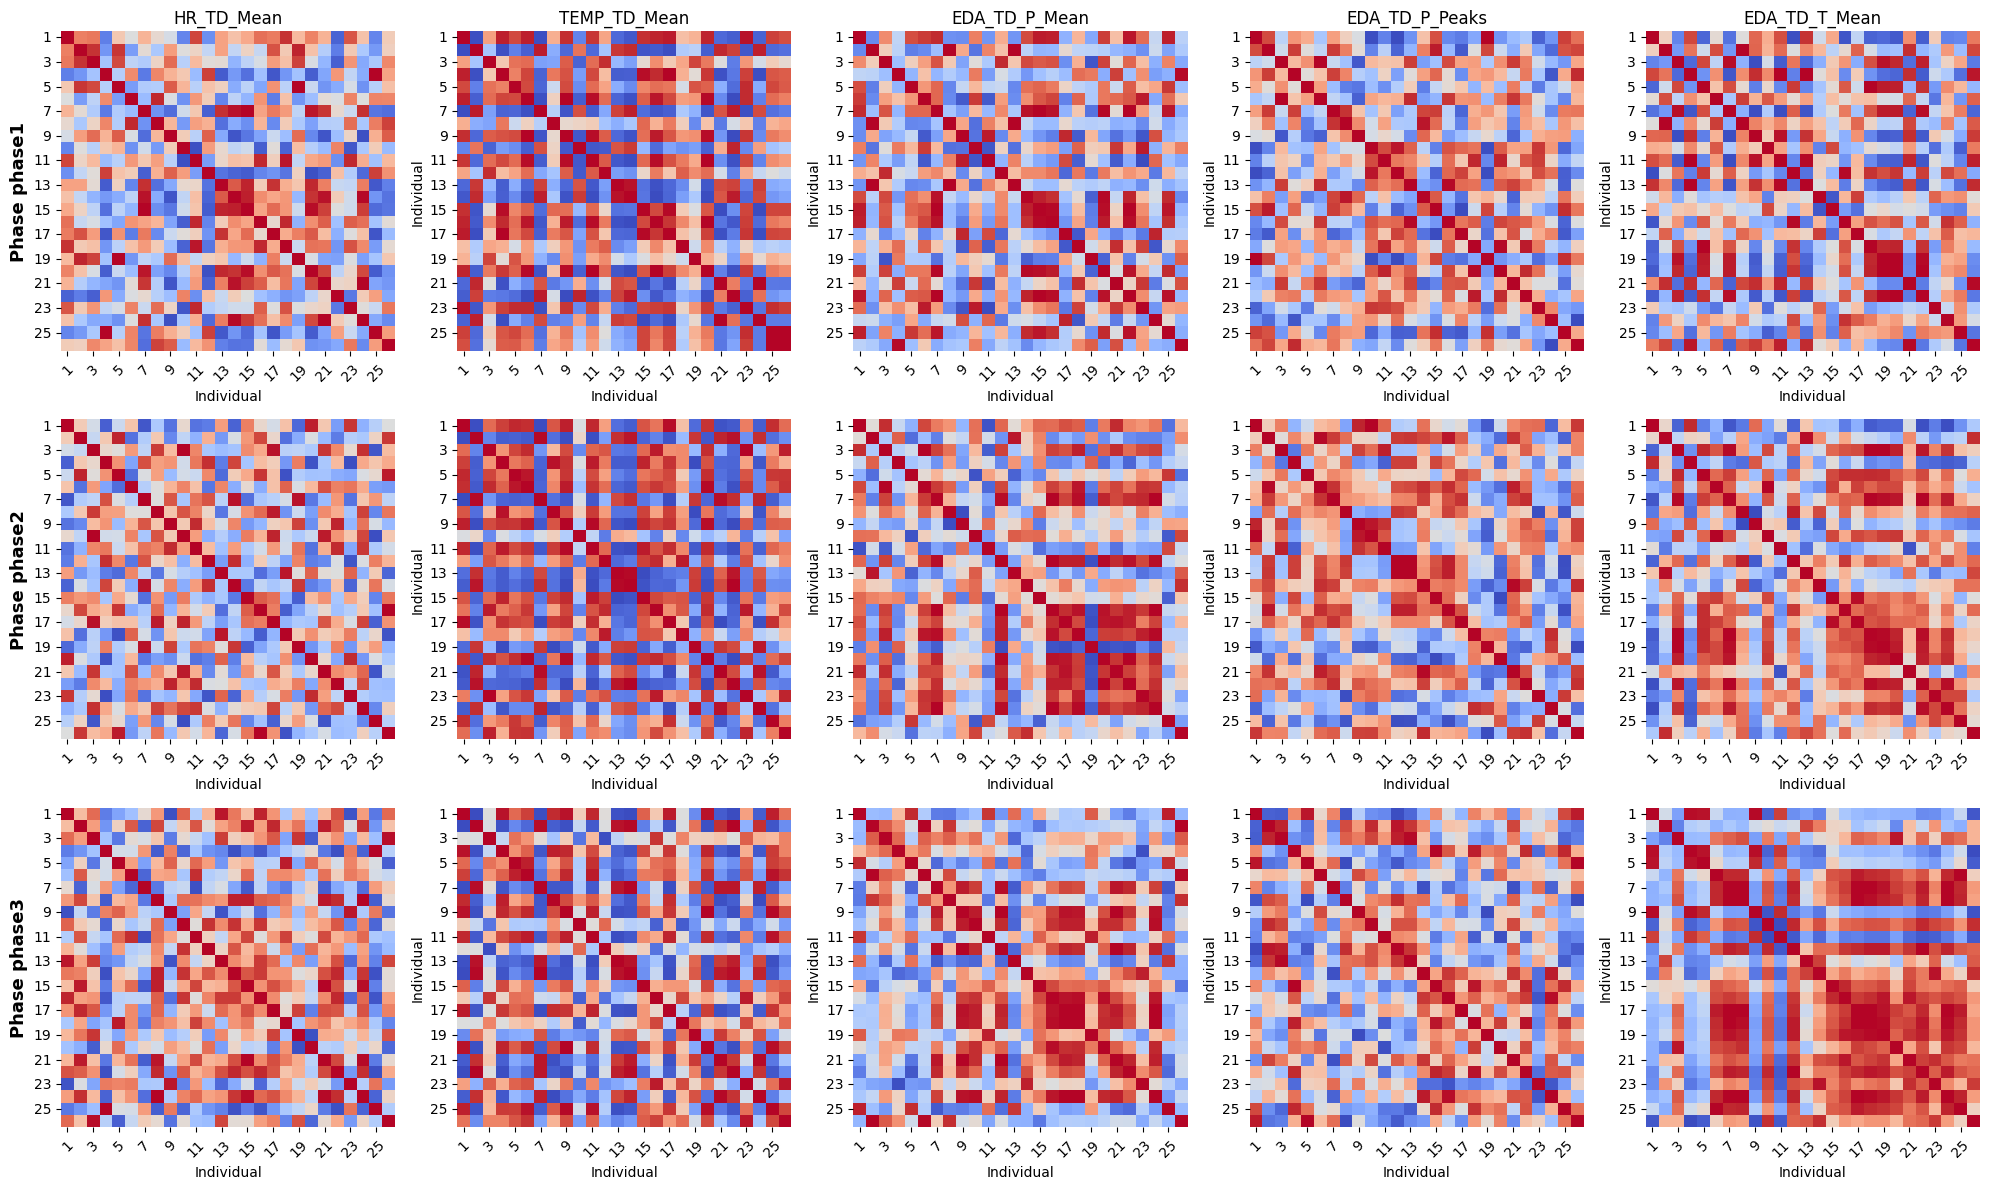

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Features to analyze ---
features = [
    'HR_TD_Mean',
    'TEMP_TD_Mean',
    'EDA_TD_P_Mean',
    'EDA_TD_P_Peaks',
    'EDA_TD_T_Mean'
]

# --- Unique phases ---
phases = sorted(df["Phase"].unique())

n_rows = len(phases)
n_cols = len(features)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))

# --- Loop through phases and features ---
for row_idx, phase in enumerate(phases):
    
    df_phase = df[df["Phase"] == phase]
    
    for col_idx, feature in enumerate(features):
        
        ax = axes[row_idx, col_idx]
        
        # Pivot: rows = rounds, columns = players
        pivot = df_phase.pivot_table(
            index="Round",
            columns="Individual",
            values=feature,
            aggfunc="mean"
        )
        
        # Compute correlation between players
        corr = pivot.corr()
        
        # Plot heatmap
        sns.heatmap(
            corr,
            ax=ax,
            cmap="coolwarm",
            center=0,
            annot=False,
            fmt=".2f",
            cbar=False
        )
        
        # Titles
        if row_idx == 0:
            ax.set_title(feature, fontsize=12)
        
        if col_idx == 0:
            ax.set_ylabel(f"Phase {phase}", fontsize=13, fontweight='bold')
        
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# --- Layout ---
plt.tight_layout()
plt.show()

## Analyse Questionnaire response

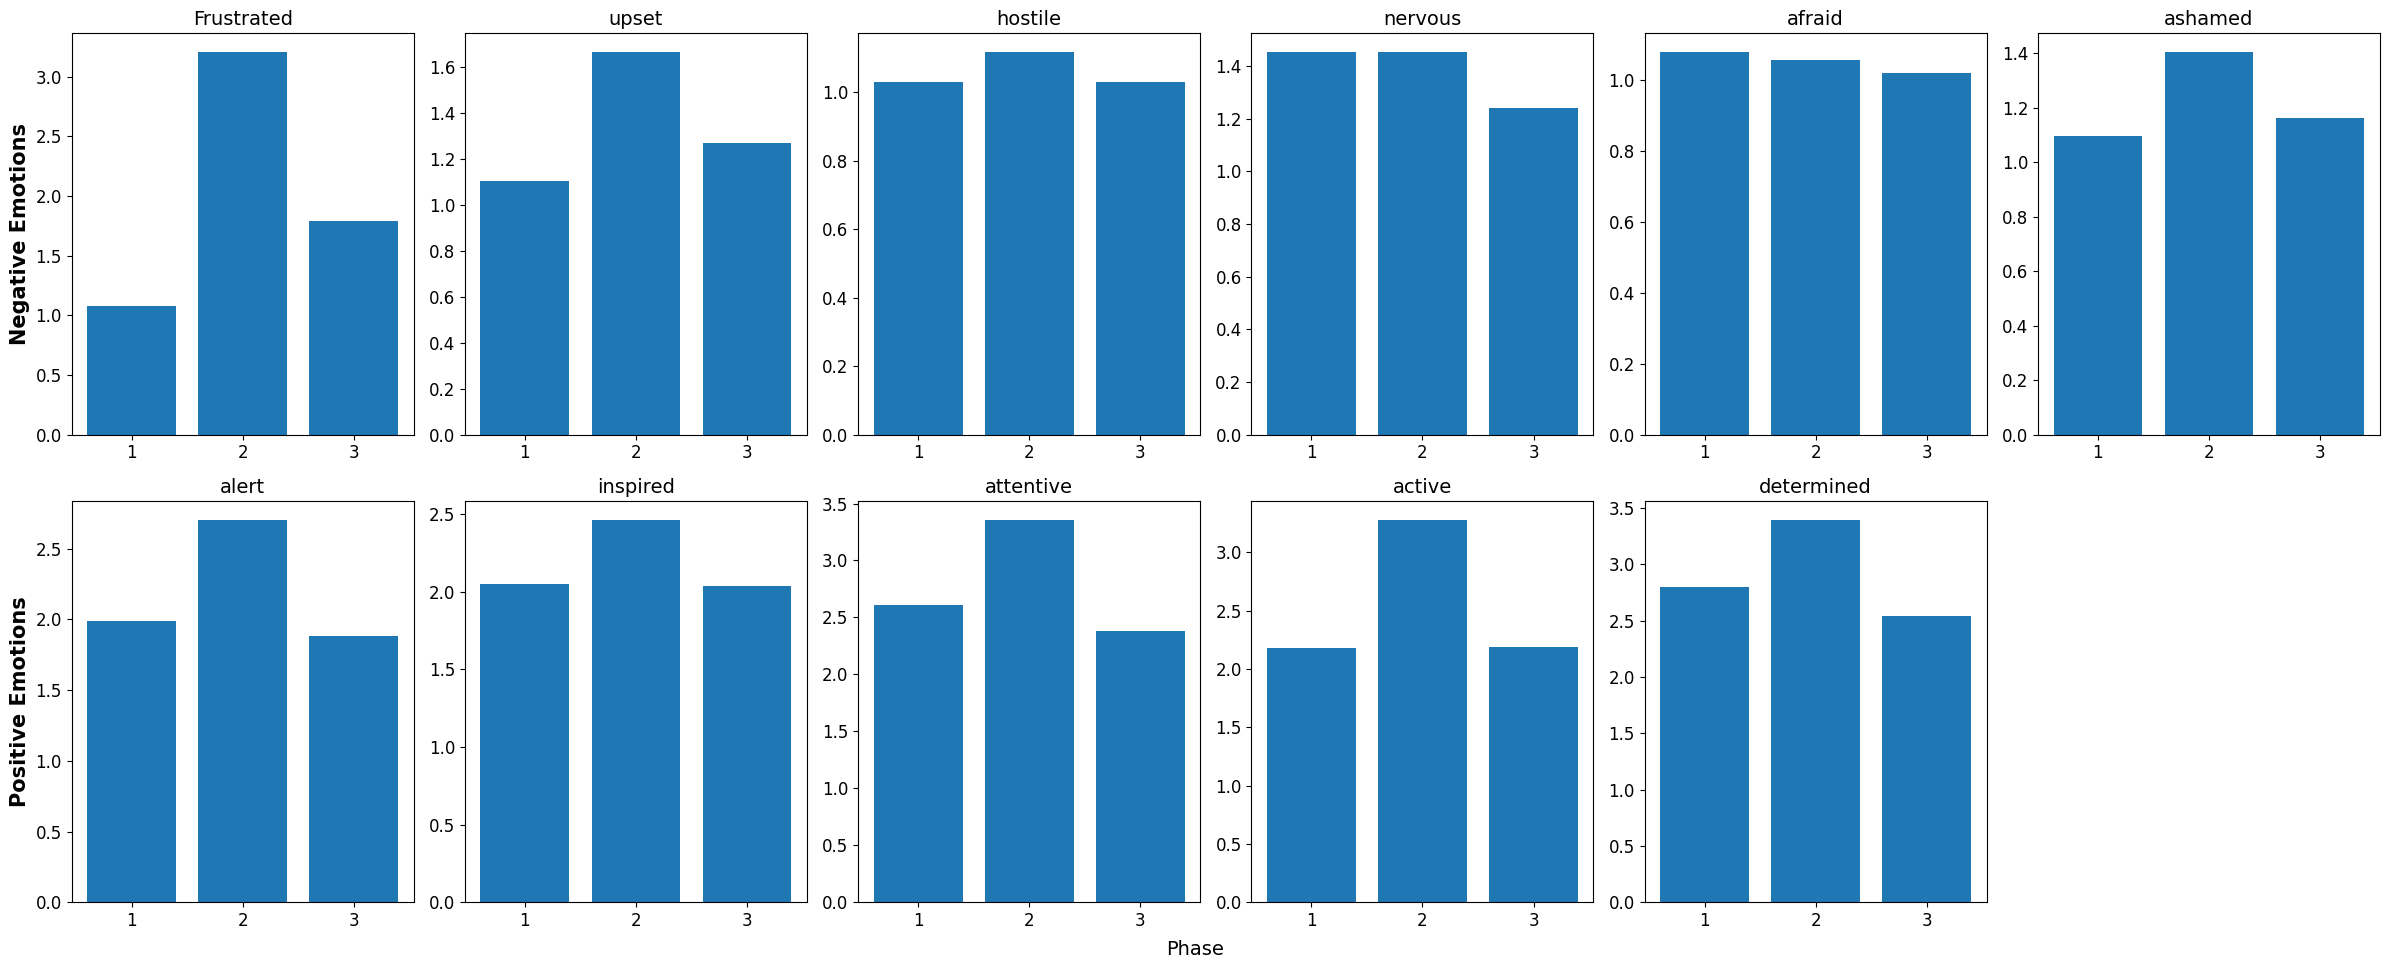

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Step 1: Questionnaire columns ---
negative_emotions = [
    "Frustrated", "upset", "hostile",
    "nervous", "afraid", "ashamed"
]

positive_emotions = [
    "alert", "inspired", "attentive",
    "active", "determined"
]

groups = {
    "Negative Emotions": negative_emotions,
    "Positive Emotions": positive_emotions
}

# --- Step 2: Phase-wise mean ---
all_cols = negative_emotions + positive_emotions
phase_means = df.groupby("Phase")[all_cols].mean()

phase_labels = ['1', '2', '3']

# --- Step 3: Create subplot grid ---
n_rows = len(groups)
n_cols = max(len(v) for v in groups.values())

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 5*n_rows))

# --- Step 4: Plot ---
for row_idx, (group_name, features) in enumerate(groups.items()):
    
    for col_idx in range(n_cols):
        ax = axes[row_idx, col_idx]
        
        if col_idx < len(features):
            feature = features[col_idx]
            values = phase_means[feature]
            
            ax.bar([0, 1, 2], values)
            
            ax.set_title(feature, fontsize=14)
            ax.set_xticks([0, 1, 2])
            ax.set_xticklabels(phase_labels, fontsize=12)
            ax.tick_params(axis='y', labelsize=12)
        
        else:
            ax.axis("off")
    
    # Row label
    axes[row_idx, 0].set_ylabel(group_name, fontsize=15, fontweight='bold')

# --- Step 5: Common X label ---
fig.text(0.5, 0.04, 'Phase', ha='center', fontsize=14)

# --- Step 6: Layout ---
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("../outputs/eda/sanity_check_of_Questionnaire_features.png") 
plt.show()

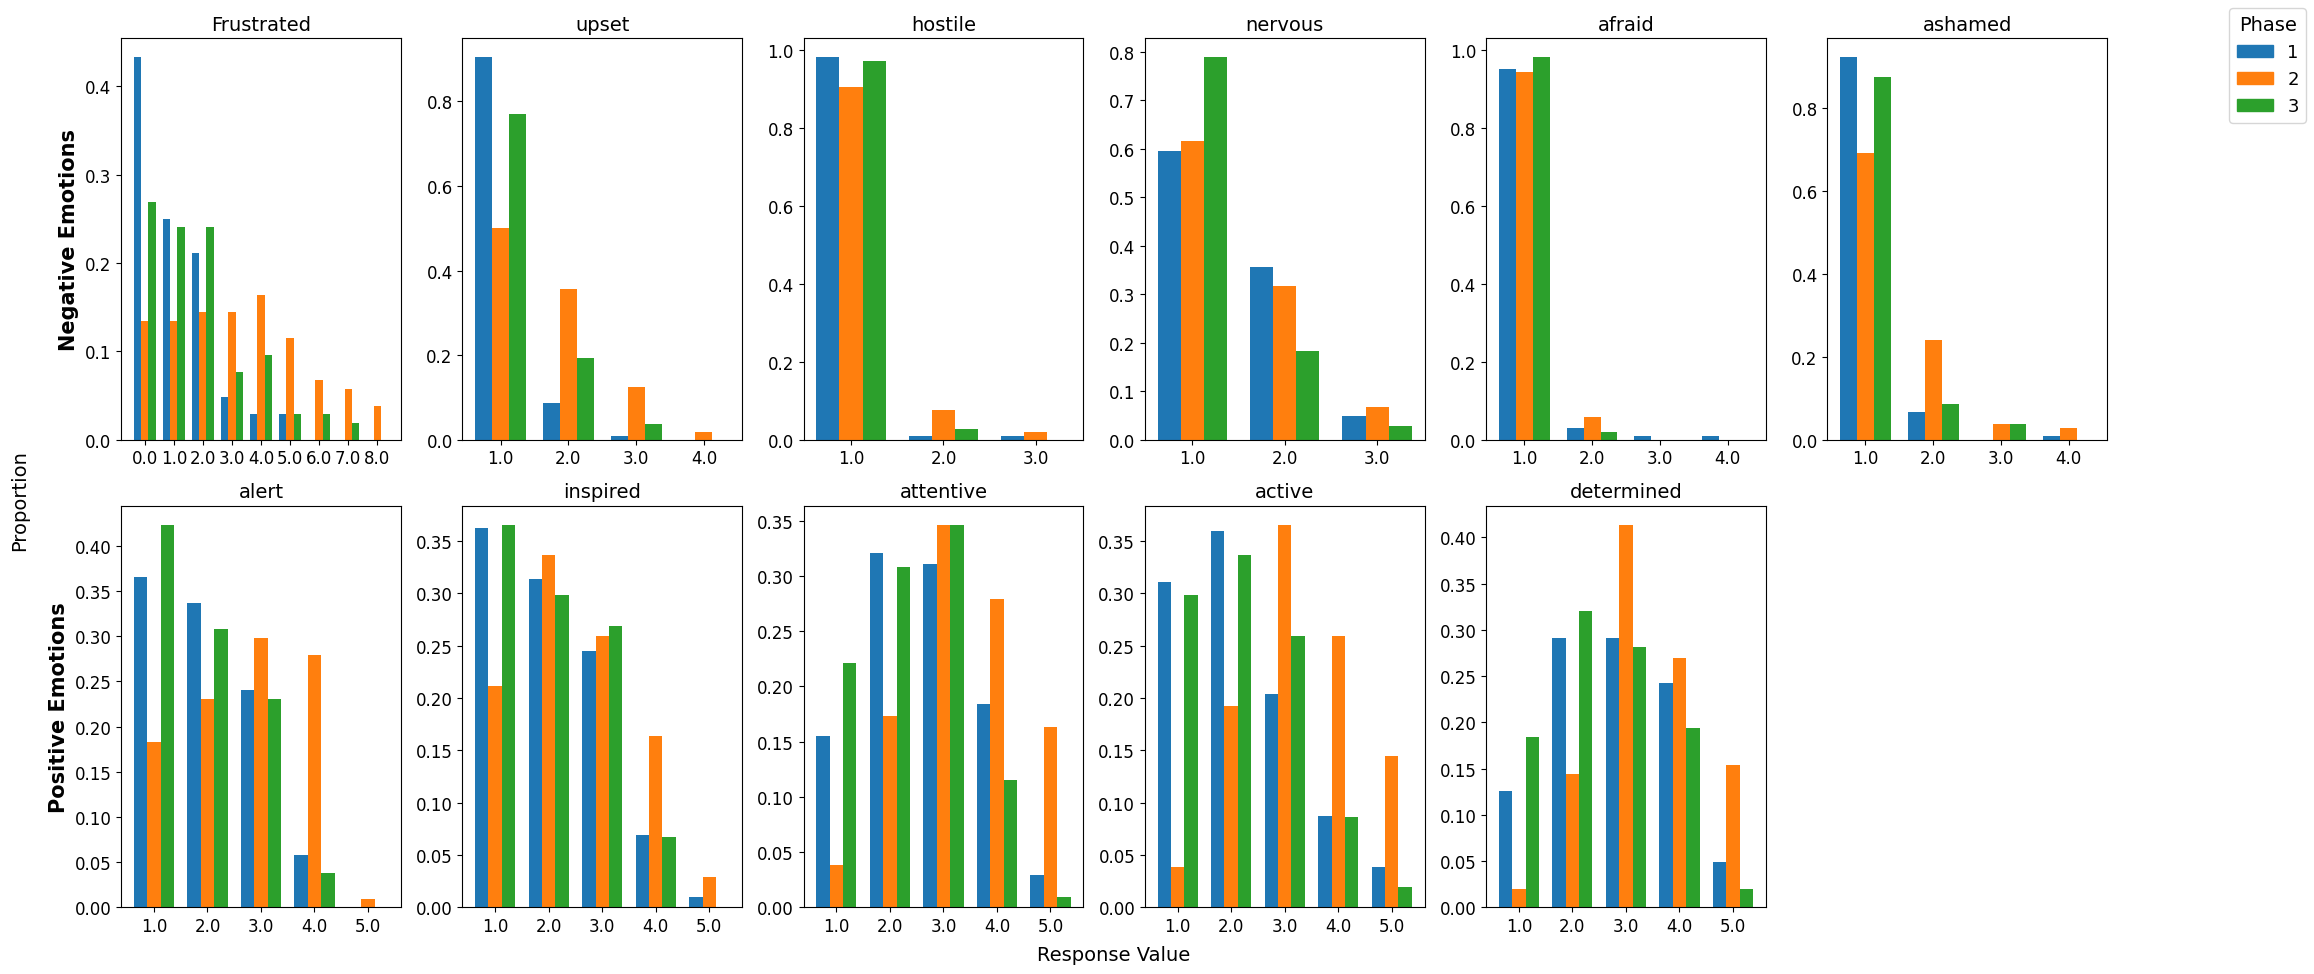

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches

# --- Step 1: Define groups ---
negative_emotions = [
    "Frustrated", "upset", "hostile",
    "nervous", "afraid", "ashamed"
]

positive_emotions = [
    "alert", "inspired", "attentive",
    "active", "determined"
]

groups = {
    "Negative Emotions": negative_emotions,
    "Positive Emotions": positive_emotions
}

# --- Step 2: Setup ---
phases = sorted(df["Phase"].unique())  # ensure consistent order
phase_labels = ['1', '2', '3']

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # fixed colors

n_rows = len(groups)
n_cols = max(len(v) for v in groups.values())

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 5*n_rows))

# --- Step 3: Plot ---
for row_idx, (group_name, features) in enumerate(groups.items()):
    
    for col_idx in range(n_cols):
        ax = axes[row_idx, col_idx]
        
        if col_idx < len(features):
            feature = features[col_idx]
            
            all_values = sorted(df[feature].dropna().unique())
            x = np.arange(len(all_values))
            width = 0.25
            
            for i, phase in enumerate(phases):
                subset = df[df["Phase"] == phase][feature]
                
                counts = (
                    subset.value_counts(normalize=True)
                    .reindex(all_values, fill_value=0)
                )
                
                ax.bar(
                    x + i*width,
                    counts,
                    width,
                    color=colors[i]
                )
            
            ax.set_title(feature, fontsize=14)
            ax.set_xticks(x + width)
            ax.set_xticklabels(all_values, fontsize=12)
            ax.tick_params(axis='y', labelsize=12)
        
        else:
            ax.axis("off")
    
    # Row label
    axes[row_idx, 0].set_ylabel(group_name, fontsize=15, fontweight='bold')

# --- Step 4: Global labels ---
fig.text(0.5, 0.04, 'Response Value', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Proportion', va='center', rotation='vertical', fontsize=14)

# --- Step 5: SINGLE clean legend (no repetition) ---
legend_handles = [
    mpatches.Patch(color=colors[0], label='1'),
    mpatches.Patch(color=colors[1], label='2'),
    mpatches.Patch(color=colors[2], label='3')
]

fig.legend(
    handles=legend_handles,
    title="Phase",
    loc='upper right',
    fontsize=13,
    title_fontsize=14
)

# --- Step 6: Layout ---
plt.tight_layout(rect=[0.05, 0.05, 0.92, 1])  # leave space for legend
plt.savefig("../outputs/eda/frequency_distribution_of_Questionnaire_features.png")
plt.show()

Questionnaire correlation

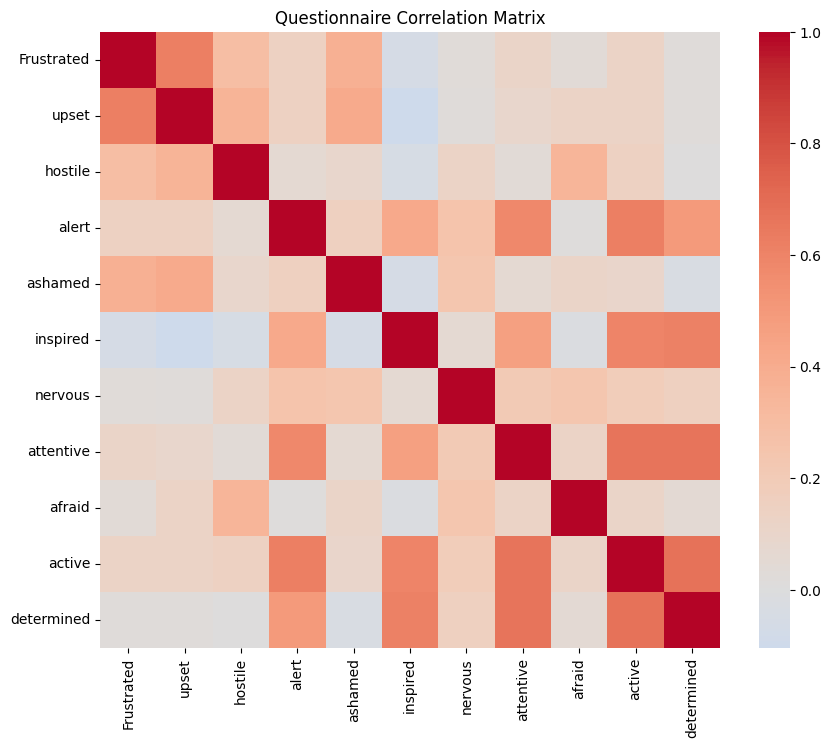

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_q = df[questionnaire_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_q, annot=False, cmap='coolwarm', center=0)
plt.title("Questionnaire Correlation Matrix")
plt.show()

## PCA analysis


Minimum number of components to reach 90% variance: 16

PCA Variance Table:


,PC,Explained Variance,Cumulative Variance
0,1,0.278465,0.278465
1,2,0.101390,0.379854
2,3,0.081902,0.461757
3,4,0.067807,0.529563
4,5,0.057193,0.586756
5,6,0.053795,0.640551
6,7,0.042513,0.683064
7,8,0.037138,0.720202
8,9,0.029608,0.749810
9,10,0.026807,0.776617


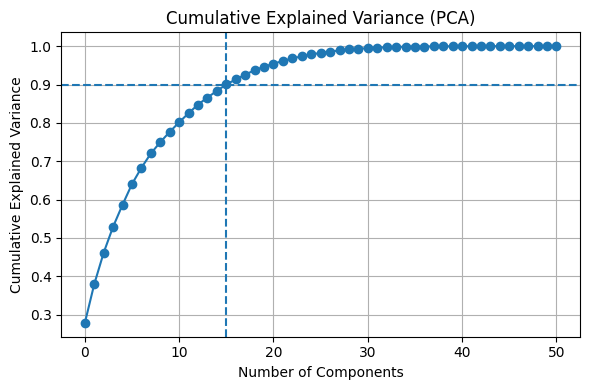

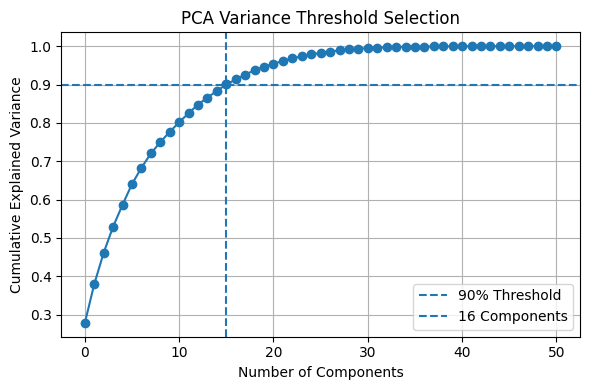

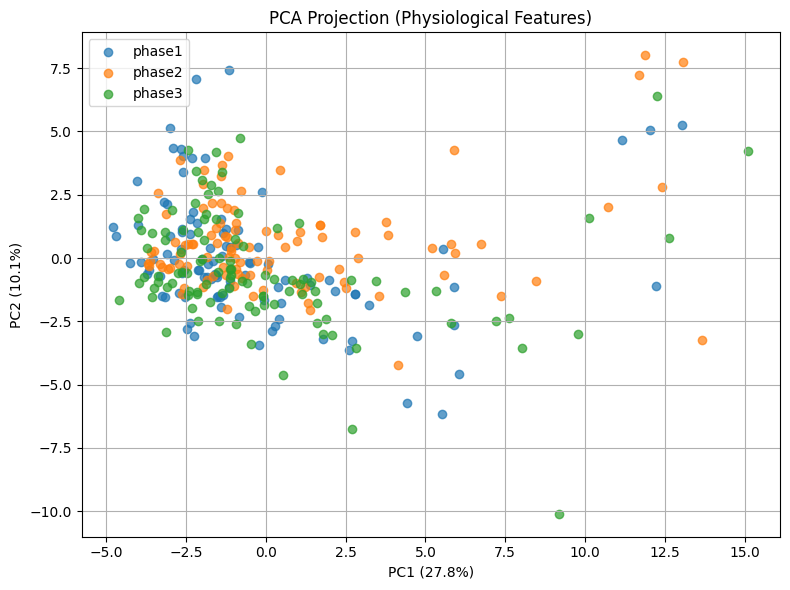

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -----------------------------
# Step 1: Prepare data
# -----------------------------
features = hr_features + temp_features + eda_p_features + eda_t_features

df_pca = df[features + ["Phase"]].dropna()

X = df_pca[features]
y = df_pca["Phase"]

# -----------------------------
# Step 2: Standardize
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Step 3: Fit PCA (all components)
# -----------------------------
pca = PCA()
pca.fit(X_scaled)

explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# -----------------------------
# Step 4: Find 90% threshold
# -----------------------------
threshold = 0.90
n_components_90 = np.argmax(cum_var >= threshold) + 1

print(f"\nMinimum number of components to reach 90% variance: {n_components_90}")

# -----------------------------
# Step 5: Variance table
# -----------------------------
variance_df = pd.DataFrame({
    "PC": np.arange(1, len(explained_var)+1),
    "Explained Variance": explained_var,
    "Cumulative Variance": cum_var
})

print("\nPCA Variance Table:")
display(variance_df)

# Save table
variance_df.to_csv("../outputs/eda/pca_variance_table.csv", index=False)

# -----------------------------
# Step 6: Cumulative variance plot
# -----------------------------
plt.figure(figsize=(6,4))
plt.plot(cum_var, marker='o')
plt.axhline(y=threshold, linestyle='--')
plt.axvline(x=n_components_90-1, linestyle='--')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance (PCA)")
plt.grid()

plt.tight_layout()
plt.savefig("../outputs/eda/pca_cumulative_explained_variance.png")
plt.show()

# -----------------------------
# Step 7: Threshold highlight plot
# -----------------------------
plt.figure(figsize=(6,4))

plt.plot(cum_var, marker='o')
plt.scatter(n_components_90-1, cum_var[n_components_90-1])

plt.axhline(y=threshold, linestyle='--', label="90% Threshold")
plt.axvline(x=n_components_90-1, linestyle='--', label=f"{n_components_90} Components")

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Threshold Selection")
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig("../outputs/eda/pca-variance-threshold.png")
plt.show()

# -----------------------------
# Step 8: PCA Projection (2D)
# -----------------------------
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Phase": y.values
})

# Color mapping
colors = {
    "phase1": "#1f77b4",
    "phase2": "#ff7f0e",
    "phase3": "#2ca02c"
}

plt.figure(figsize=(8,6))

for phase in sorted(pca_df["Phase"].unique()):
    subset = pca_df[pca_df["Phase"] == phase]
    
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=phase,
        alpha=0.7,
        color=colors[phase]
    )

plt.xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA Projection (Physiological Features)")
plt.legend()
plt.grid()

plt.tight_layout()

# Save PCA plot
plt.savefig("../outputs/eda/pca_projection.png")

# Show in notebook
plt.show()



Components needed for 90% variance: 16

Top contributors to PC1:


EDA_TD_P_Max          0.248801
EDA_TD_P_std          0.245658
EDA_TD_T_std          0.240675
EDA_TD_T_Slope_max    0.239415
EDA_TD_P_Slope_max    0.238414
EDA_TD_P_Slope_min    0.234340
EDA_TD_T_Slope_min    0.231957
EDA_TD_P_AUC          0.224542
EDA_TD_P_Mean         0.223582
EDA_TD_T_Max          0.214833
Name: PC1, dtype: float64


Top contributors to PC2:


HR_TD_Max          0.320550
HR_TD_Mean         0.311302
HR_TD_Median       0.285152
HR_TD_AUC          0.280776
EDA_TD_T_Min       0.246871
HR_TD_std          0.237337
EDA_TD_T_Mean      0.199520
EDA_TD_T_Median    0.197776
HR_TD_Slope_min    0.196032
EDA_TD_T_AUC       0.193856
Name: PC2, dtype: float64

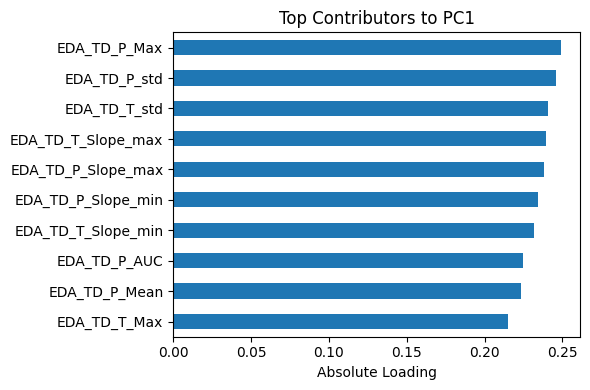

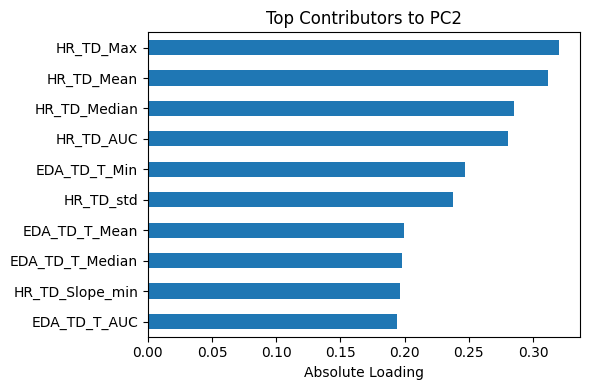


Global Feature Contributions (90% variance):


,Feature,Contribution
19,TEMP_TD_Skew,0.055466
18,TEMP_TD_Kurtosis,0.052863
17,TEMP_TD_AUC,0.038783
6,HR_TD_Kurtosis,0.035839
20,TEMP_TD_Slope_min,0.034605
50,EDA_TD_T_Slope,0.029730
49,EDA_TD_T_Slope_mean,0.029578
30,EDA_TD_P_Kurtosis,0.028657
27,EDA_TD_P_Min,0.028301
10,HR_TD_Slope_mean,0.027557


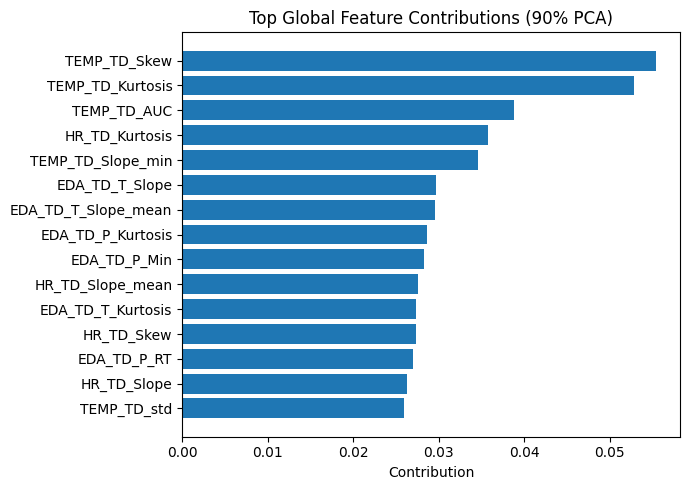


Contribution by Signal Type:


Category
EDA     0.392543
HR      0.270829
TEMP    0.336628
Name: Contribution, dtype: float64

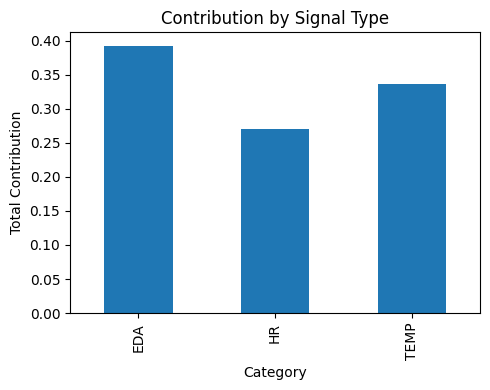

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -----------------------------
# Setup
# -----------------------------
features = hr_features + temp_features + eda_p_features + eda_t_features

df_pca = df[features].dropna()

# -----------------------------
# Standardize
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# -----------------------------
# PCA Fit
# -----------------------------
pca = PCA()
pca.fit(X_scaled)

explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# -----------------------------
# Select 90% components
# -----------------------------
threshold = 0.90
n_components_90 = np.argmax(cum_var >= threshold) + 1

print(f"\nComponents needed for 90% variance: {n_components_90}")

# -----------------------------
# Loadings DataFrame
# -----------------------------
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(features))],
    index=features
)

# -----------------------------
# PC1 and PC2 Top Contributors
# -----------------------------
pc1_top = loadings_df["PC1"].abs().sort_values(ascending=False).head(10)
pc2_top = loadings_df["PC2"].abs().sort_values(ascending=False).head(10)

print("\nTop contributors to PC1:")
display(pc1_top)

print("\nTop contributors to PC2:")
display(pc2_top)

# Save
pc1_top.to_csv("../outputs/eda/pc1_top_contributors.csv")
pc2_top.to_csv("../outputs/eda/pc2_top_contributors.csv")

# -----------------------------
# Plot PC1
# -----------------------------
plt.figure(figsize=(6,4))
pc1_top.sort_values().plot(kind='barh')
plt.title("Top Contributors to PC1")
plt.xlabel("Absolute Loading")
plt.tight_layout()
plt.savefig("../outputs/eda/pc1_top_features.png")
plt.show()

# -----------------------------
# Plot PC2
# -----------------------------
plt.figure(figsize=(6,4))
pc2_top.sort_values().plot(kind='barh')
plt.title("Top Contributors to PC2")
plt.xlabel("Absolute Loading")
plt.tight_layout()
plt.savefig("../outputs/eda/pc2_top_features.png")
plt.show()

# -----------------------------
# GLOBAL CONTRIBUTION (90%)
# -----------------------------
loadings = pca.components_.T[:, :n_components_90]

contributions = loadings ** 2
global_contribution = contributions.sum(axis=1)

# Normalize
global_contribution = global_contribution / global_contribution.sum()

global_df = pd.DataFrame({
    "Feature": features,
    "Contribution": global_contribution
}).sort_values(by="Contribution", ascending=False)

print("\nGlobal Feature Contributions (90% variance):")
display(global_df.head(15))

# Save
global_df.to_csv("../outputs/eda/pca_global_contributions.csv", index=False)

# -----------------------------
# Plot Global Contributions
# -----------------------------
top_n = 15
top_global = global_df.head(top_n)

plt.figure(figsize=(7,5))
plt.barh(top_global["Feature"], top_global["Contribution"])
plt.gca().invert_yaxis()

plt.title("Top Global Feature Contributions (90% PCA)")
plt.xlabel("Contribution")

plt.tight_layout()
plt.savefig("../outputs/eda/global_feature_contributions.png")
plt.show()

# -----------------------------
# Optional: Group by signal type
# -----------------------------
def categorize(feature):
    if "HR" in feature:
        return "HR"
    elif "TEMP" in feature:
        return "TEMP"
    elif "EDA" in feature:
        return "EDA"

global_df["Category"] = global_df["Feature"].apply(categorize)

grouped = global_df.groupby("Category")["Contribution"].sum()

print("\nContribution by Signal Type:")
display(grouped)

# Plot grouped contributions
plt.figure(figsize=(5,4))
grouped.plot(kind='bar')
plt.title("Contribution by Signal Type")
plt.ylabel("Total Contribution")
plt.tight_layout()
plt.savefig("../outputs/eda/signal_group_contribution.png")
plt.show()

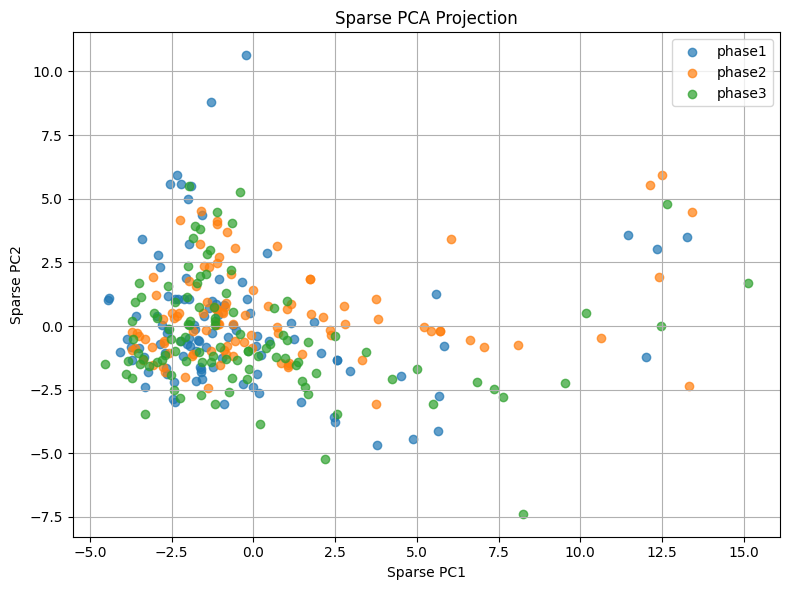


Sparse PCA Loadings (non-zero importance):
                         SPC1      SPC2
HR_TD_Mean                NaN  0.402333
HR_TD_Median              NaN  0.368110
HR_TD_std                 NaN  0.270399
HR_TD_Min            0.004865  0.246224
HR_TD_Max                 NaN  0.401005
HR_TD_AUC                 NaN  0.358384
HR_TD_Skew          -0.010949       NaN
HR_TD_Slope_min           NaN -0.222533
HR_TD_Slope_max     -0.000440  0.156330
HR_TD_Slope          0.000143       NaN
TEMP_TD_Mean         0.177068 -0.024975
TEMP_TD_Median       0.177197 -0.026238
TEMP_TD_std         -0.007289  0.030857
TEMP_TD_Min          0.175563 -0.032593
TEMP_TD_Max          0.174498 -0.016217
TEMP_TD_AUC          0.070129       NaN
TEMP_TD_Kurtosis          NaN  0.031697
TEMP_TD_Skew        -0.002841       NaN
TEMP_TD_Slope_min         NaN -0.112330
TEMP_TD_Slope_max         NaN  0.103237
TEMP_TD_Slope_mean   0.011592 -0.004606
TEMP_TD_Slope        0.013124 -0.001018
EDA_TD_P_Mean        0.231485  0.073

In [33]:
from sklearn.decomposition import SparsePCA

# -----------------------------
# Step 1: Standardized data (reuse)
# -----------------------------
# X_scaled already computed

# -----------------------------
# Step 2: Fit Sparse PCA
# -----------------------------
spca = SparsePCA(n_components=2, alpha=1, random_state=42)
X_spca = spca.fit_transform(X_scaled)

# -----------------------------
# Step 3: Create dataframe
# -----------------------------
spca_df = pd.DataFrame({
    "SPC1": X_spca[:, 0],
    "SPC2": X_spca[:, 1],
    "Phase": y.values
})

# -----------------------------
# Step 4: Plot
# -----------------------------
plt.figure(figsize=(8,6))

for phase in sorted(spca_df["Phase"].unique()):
    subset = spca_df[spca_df["Phase"] == phase]
    
    plt.scatter(
        subset["SPC1"],
        subset["SPC2"],
        label=phase,
        alpha=0.7,
        color=colors[phase]
    )

plt.xlabel("Sparse PC1")
plt.ylabel("Sparse PC2")
plt.title("Sparse PCA Projection")
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig("../outputs/eda/sparse_pca_projection.png")
plt.show()

# -----------------------------
# Step 5: Sparse Loadings
# -----------------------------
spca_loadings = pd.DataFrame(
    spca.components_.T,
    columns=["SPC1", "SPC2"],
    index=features
)

print("\nSparse PCA Loadings (non-zero importance):")
print(spca_loadings.replace(0, np.nan).dropna(how='all'))